<a href="https://colab.research.google.com/github/davesagit123/blank-app/blob/main/deepseek_all_metric_version.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import pandas as pd

# ============================
# 1. INPUT DATA
# ============================

data_last3 = {
    "Runner": ["Ceolwulf","Gringotts","Lindermann","Midnight Dynamite","Green Spaces",
               "Autumn Glow","Aeliana","Fangirl","Idle Flyer","Lady Shenandoah","Sheza Alibi"],
    "L800": [-3.06, -3.06, -2.87, -3.03, -2.95, -3.43, -4.36, -3.24, -2.88, -2.65, -3.25],
    "L600": [-2.42, -2.74, -1.91, -2.68, -2.25, -2.90, -3.43, -2.87, -2.43, -2.23, -2.58],
    "L400": [-1.53, -2.13, -1.02, -1.85, -1.54, -2.06, -2.26, -2.10, -1.64, -1.56, -1.99],
    "L200": [-0.44, -0.89, -0.14, -0.79, -0.52, -0.79, -0.98, -0.86, -0.64, -0.59, -0.95]
}

df3 = pd.DataFrame(data_last3)

# ============================
# 2. WEAKEST & STRONGEST LINK
# ============================

sectionals = ["L800","L600","L400","L200"]

# Weakest link = slowest sectional (max value)
df3["Weakest_Link"] = df3[sectionals].max(axis=1)

# Strongest link = fastest sectional (min value)
df3["Strongest_Link"] = df3[sectionals].min(axis=1)

# ============================
# 3. NORMALIZED INDEX (0–1)
# ============================

# Lower is better → invert weakest link
df3["Weak_Index"] = (df3["Weakest_Link"] - df3["Weakest_Link"].min()) / \
                    (df3["Weakest_Link"].max() - df3["Weakest_Link"].min())

# Strongest link: lower = better → invert
df3["Strong_Index"] = (df3["Strongest_Link"] - df3["Strongest_Link"].min()) / \
                      (df3["Strongest_Link"].max() - df3["Strongest_Link"].min())

# ============================
# 4. DISPLAY RESULTS
# ============================

df3_sorted = df3[["Runner","Weakest_Link","Strongest_Link","Weak_Index","Strong_Index"]]
df3_sorted


,Runner,Weakest_Link,Strongest_Link,Weak_Index,Strong_Index
0,Ceolwulf,-0.44,-3.06,0.642857,0.760234
1,Gringotts,-0.89,-3.06,0.107143,0.760234
2,Lindermann,-0.14,-2.87,1.000000,0.871345
3,Midnight Dynamite,-0.79,-3.03,0.226190,0.777778
4,Green Spaces,-0.52,-2.95,0.547619,0.824561
5,Autumn Glow,-0.79,-3.43,0.226190,0.543860
6,Aeliana,-0.98,-4.36,0.000000,0.000000
7,Fangirl,-0.86,-3.24,0.142857,0.654971
8,Idle Flyer,-0.64,-2.88,0.404762,0.865497
9,Lady Shenandoah,-0.59,-2.65,0.464286,1.000000


updated version

In [29]:
import pandas as pd
import numpy as np

# ============================
# 1. INPUT DATA (Last 3 runs)
# ============================

data_last3 = {
    "Runner": ["Ceolwulf","Gringotts","Lindermann","Midnight Dynamite","Green Spaces",
               "Autumn Glow","Aeliana","Fangirl","Idle Flyer","Lady Shenandoah","Sheza Alibi"],
    "L800": [-3.06, -3.06, -2.87, -3.03, -2.95, -3.43, -4.36, -3.24, -2.88, -2.65, -3.25],
    "L600": [-2.42, -2.74, -1.91, -2.68, -2.25, -2.90, -3.43, -2.87, -2.43, -2.23, -2.58],
    "L400": [-1.53, -2.13, -1.02, -1.85, -1.54, -2.06, -2.26, -2.10, -1.64, -1.56, -1.99],
    "L200": [-0.44, -0.89, -0.14, -0.79, -0.52, -0.79, -0.98, -0.86, -0.64, -0.59, -0.95]
}

df = pd.DataFrame(data_last3)
sectionals = ["L800","L600","L400","L200"]

# ============================
# 2. Z-SCORE NORMALIZATION
# ============================

df_z = df.copy()
for sec in sectionals:
    mu = df[sec].mean()
    sd = df[sec].std()
    df_z[sec+"_z"] = (df[sec] - mu) / sd

# ============================
# 3. MIN-MAX NORMALIZATION
# ============================

df_mm = df.copy()
for sec in sectionals:
    mn = df[sec].min()
    mx = df[sec].max()
    df_mm[sec+"_mm"] = (df[sec] - mn) / (mx - mn)

# ============================
# 4. TRUE WEAKEST & STRONGEST LINK (Z-SCORE)
# ============================

# Remember: lower is better → higher z = worse
df_z["Weakest_Link_z"] = df_z[[s+"_z" for s in sectionals]].max(axis=1)
df_z["Strongest_Link_z"] = df_z[[s+"_z" for s in sectionals]].min(axis=1)

# ============================
# 5. OUTPUT
# ============================

cols_out = ["Runner"] + [s+"_z" for s in sectionals] + ["Weakest_Link_z","Strongest_Link_z"]
df_z[cols_out]


,Runner,L800_z,L600_z,L400_z,L200_z,Weakest_Link_z,Strongest_Link_z
0,Ceolwulf,0.225930,0.404551,0.705812,0.982851,0.982851,0.225930
1,Gringotts,0.225930,-0.377877,-0.928700,-0.786281,0.225930,-0.928700
2,Lindermann,0.647532,1.651546,2.095148,2.162273,2.162273,0.647532
3,Midnight Dynamite,0.292499,-0.231172,-0.165928,-0.393141,0.292499,-0.393141
4,Green Spaces,0.470015,0.820216,0.678570,0.668339,0.820216,0.470015
5,Autumn Glow,-0.595084,-0.769091,-0.738007,-0.393141,-0.393141,-0.769091
6,Aeliana,-2.658714,-2.064988,-1.282845,-1.140108,-1.140108,-2.658714
7,Fangirl,-0.173482,-0.695739,-0.846975,-0.668339,-0.173482,-0.846975
8,Idle Flyer,0.625342,0.380100,0.406152,0.196570,0.625342,0.196570
9,Lady Shenandoah,1.135703,0.869118,0.624087,0.393141,1.135703,0.393141


version 3

In [30]:
import pandas as pd
import numpy as np

# ============================
# 1. INPUT DATA (Last 3 runs)
# ============================

data_last3 = {
    "Runner": ["Ceolwulf","Gringotts","Lindermann","Midnight Dynamite","Green Spaces",
               "Autumn Glow","Aeliana","Fangirl","Idle Flyer","Lady Shenandoah","Sheza Alibi"],
    "Runner_Time": [-13.96, -16.56, -19.44, -13.07, -15.00, -22.24, -26.71, -16.30, -16.11, -17.32, -21.16],
    "L800": [-3.06, -3.06, -2.87, -3.03, -2.95, -3.43, -4.36, -3.24, -2.88, -2.65, -3.25],
    "L600": [-2.42, -2.74, -1.91, -2.68, -2.25, -2.90, -3.43, -2.87, -2.43, -2.23, -2.58],
    "L400": [-1.53, -2.13, -1.02, -1.85, -1.54, -2.06, -2.26, -2.10, -1.64, -1.56, -1.99],
    "L200": [-0.44, -0.89, -0.14, -0.79, -0.52, -0.79, -0.98, -0.86, -0.64, -0.59, -0.95]
}

df = pd.DataFrame(data_last3)
sectionals = ["L800","L600","L400","L200"]

# ============================
# 2. Z-SCORE NORMALIZATION
# ============================

df_z = df.copy()
for sec in sectionals:
    mu = df[sec].mean()
    sd = df[sec].std()
    df_z[sec+"_z"] = (df[sec] - mu) / sd

# Final time z-score
muT = df["Runner_Time"].mean()
sdT = df["Runner_Time"].std()
df_z["Time_z"] = (df["Runner_Time"] - muT) / sdT

# ============================
# 3. K-WEIBULL FUNCTIONS
# ============================

def expK(x, K):
    return (np.sqrt(1 + (K**2)*(x**2)) + K*x)**(1/K)

def S_K(z, K=0.5, m=2.0):
    return expK(-(abs(z)**m), K)

# ============================
# 4. FRAGILITY & PEAK SCORES
# ============================

# Weakest-link fragility (product of survival)
df_z["Fragility"] = 1 - df_z[[s+"_z" for s in sectionals]].apply(
    lambda row: np.prod([S_K(z) for z in row]), axis=1
)

# Strongest-link peak ability
df_z["Peak_z"] = df_z[[s+"_z" for s in sectionals]].min(axis=1)
df_z["Peak_K"] = df_z["Peak_z"].apply(lambda z: S_K(z))

# ============================
# 5. OUTPUT
# ============================

df_out = df_z[[
    "Runner","Time_z",
    "L800_z","L600_z","L400_z","L200_z",
    "Fragility","Peak_z","Peak_K"
]]

df_out


,Runner,Time_z,L800_z,L600_z,L400_z,L200_z,Fragility,Peak_z,Peak_K
0,Ceolwulf,0.993103,0.225930,0.404551,0.705812,0.982851,0.805939,0.225930,0.950242
1,Gringotts,0.352102,0.225930,-0.377877,-0.928700,-0.786281,0.806073,-0.928700,0.432675
2,Lindermann,-0.357930,0.647532,1.651546,2.095148,2.162273,0.999860,0.647532,0.659492
3,Midnight Dynamite,1.212523,0.292499,-0.231172,-0.165928,-0.393141,0.274505,-0.393141,0.856924
4,Green Spaces,0.736703,0.470015,0.820216,0.678570,0.668339,0.831475,0.470015,0.802143
5,Autumn Glow,-1.048238,-0.595084,-0.769091,-0.738007,-0.393141,0.803687,-0.769091,0.558109
6,Aeliana,-2.150267,-2.658714,-2.064988,-1.282845,-1.140108,0.999937,-2.658714,0.019250
7,Fangirl,0.416202,-0.173482,-0.695739,-0.846975,-0.668339,0.808984,-0.846975,0.495191
8,Idle Flyer,0.463045,0.625342,0.380100,0.406152,0.196570,0.521148,0.196570,0.962099
9,Lady Shenandoah,0.164733,1.135703,0.869118,0.624087,0.393141,0.917408,0.393141,0.856924


stress levels

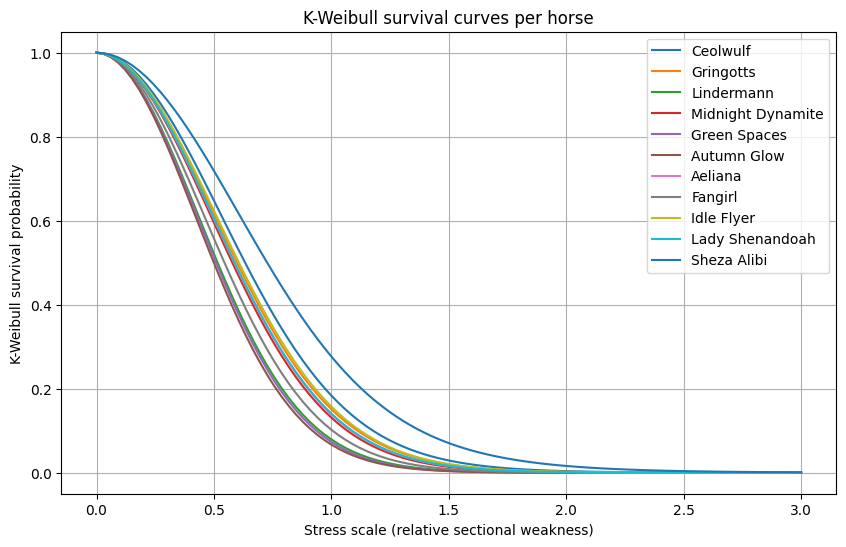

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# Use df_z / df_out from previous cells
horses = df_out["Runner"].tolist()
sectional_cols = ["L800_z","L600_z","L400_z","L200_z"]

def expK(x, K):
    return (np.sqrt(1 + (K**2)*(x**2)) + K*x)**(1/K)

def survival_curve(z_values, K=0.5, m=2.0, s_grid=None):
    if s_grid is None:
        s_grid = np.linspace(0, 3, 100)  # stress scale
    z_max = max(abs(z) for z in z_values) + 1e-6
    S = []
    for s in s_grid:
        S_i = [expK(-(abs(s * z / z_max)**m), K) for z in z_values]
        S.append(np.prod(S_i))
    return s_grid, np.array(S)

plt.figure(figsize=(10,6))
for i, row in df_out.iterrows():
    z_vals = [row[c] for c in sectional_cols]
    s, S = survival_curve(z_vals, K=0.5, m=2.0)
    plt.plot(s, S, label=row["Runner"])

plt.xlabel("Stress scale (relative sectional weakness)")
plt.ylabel("K-Weibull survival probability")
plt.title("K-Weibull survival curves per horse")
plt.legend()
plt.grid(True)
plt.show()


predictive model

In [32]:
# Copy df_out from earlier
df_pred = df_out.copy()

# Standardize components
for col in ["Fragility","Peak_K","Time_z"]:
    mu = df_pred[col].mean()
    sd = df_pred[col].std()
    df_pred[col+"_std"] = (df_pred[col] - mu) / sd

# Updated weights to prioritize speed over robustness
w_frag = 0.2   # less penalty for fragility
w_peak = -0.4  # more reward for peak
w_time = 0.4   # more reward for fast time (negative z)

df_pred["Score"] = (
    w_frag * df_pred["Fragility_std"] +
    w_peak * df_pred["Peak_K_std"] +
    w_time * df_pred["Time_z_std"]
)

df_pred_sorted = df_pred[["Runner","Score","Fragility","Peak_K","Time_z"]].sort_values("Score")
df_pred_sorted

,Runner,Score,Fragility,Peak_K,Time_z
8,Idle Flyer,-0.505653,0.521148,0.962099,0.463045
3,Midnight Dynamite,-0.295513,0.274505,0.856924,1.212523
5,Autumn Glow,-0.288195,0.803687,0.558109,-1.048238
9,Lady Shenandoah,-0.104966,0.917408,0.856924,0.164733
0,Ceolwulf,-0.007301,0.805939,0.950242,0.993103
10,Sheza Alibi,0.018036,0.737955,0.367022,-0.781977
2,Lindermann,0.034920,0.999860,0.659492,-0.357930
4,Green Spaces,0.117458,0.831475,0.802143,0.736703
6,Aeliana,0.196097,0.999937,0.019250,-2.150267
7,Fangirl,0.388891,0.808984,0.495191,0.416202


deepseek version

HORSE RACING WEAK-LINK ANALYSIS - PROPER DIRECTION

Final Rankings (lower composite score = better):
 Rank            Runner  Composite_Score
    1         Gringotts            0.274
    2           Fangirl            0.285
    3           Aeliana            0.300
    4       Sheza Alibi            0.316
    5       Autumn Glow            0.330
    6 Midnight Dynamite            0.422
    7        Idle Flyer            0.448
    8   Lady Shenandoah            0.452
    9      Green Spaces            0.538
   10          Ceolwulf            0.582
   11        Lindermann            0.793


Detailed Metrics (remember: more negative Avg_Speed and Weakest_Link = better):
           Runner  Avg_Speed  Weakest_Link   Gap  Pct_Competitive
        Gringotts     -2.167        -0.866 2.110             0.85
          Fangirl     -2.264        -0.848 2.404             1.00
          Aeliana     -2.626        -0.956 3.112             1.00
      Sheza Alibi     -2.039        -0.866 2.132             

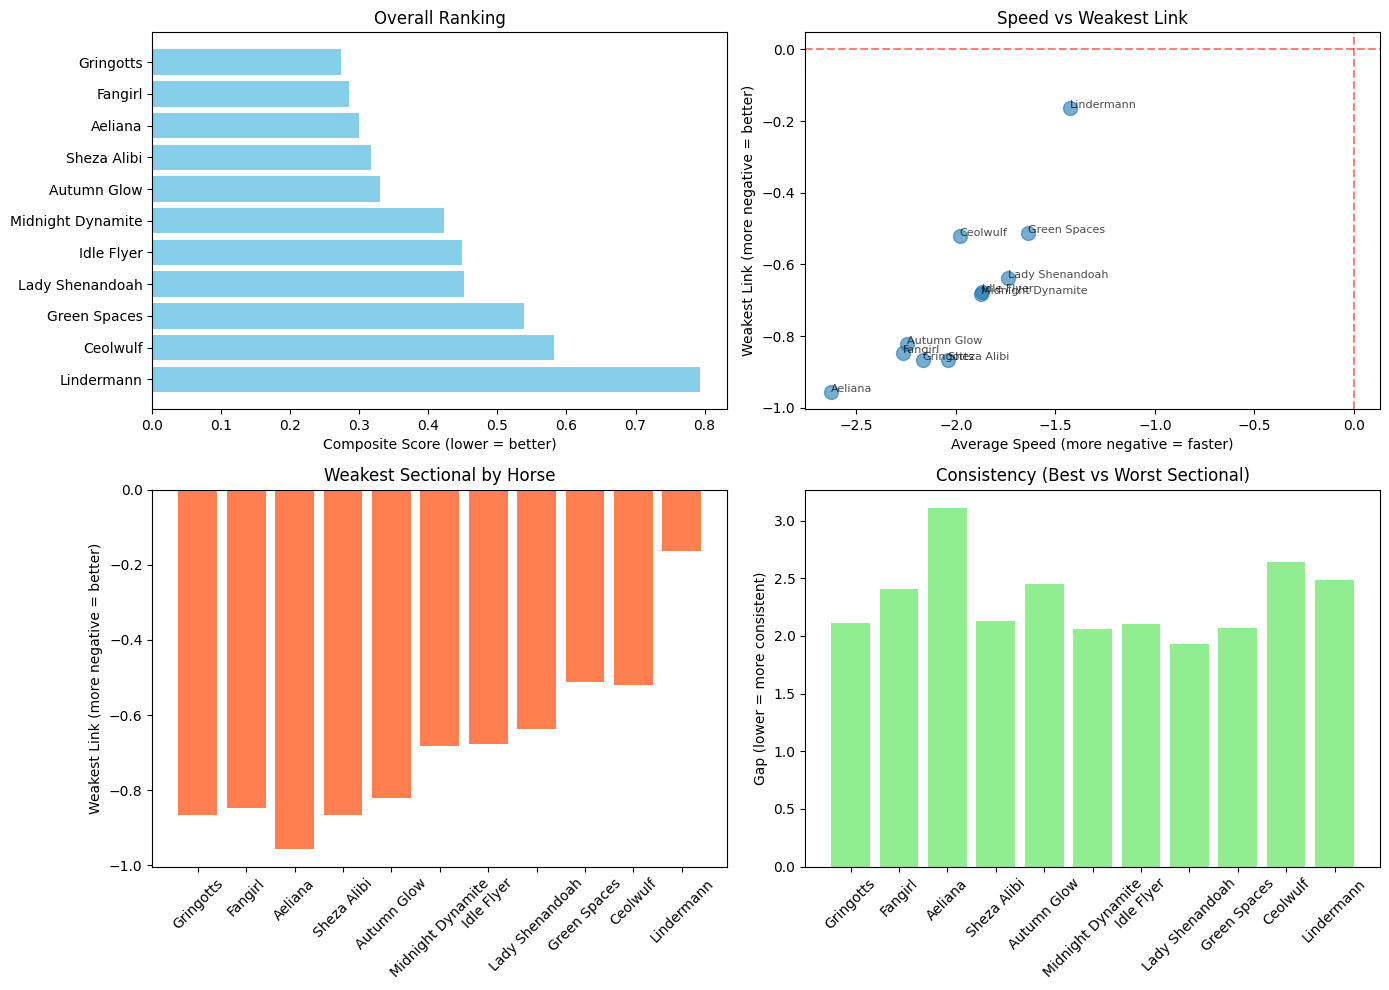


KEY INSIGHTS

Gringotts:
  - Average Speed: -2.17L
  - Weakest Sectional: -0.87L
  - Best-Worst Gap: 2.11L
  - Competitive Sectionals: 85%

Fangirl:
  - Average Speed: -2.26L
  - Weakest Sectional: -0.85L
  - Best-Worst Gap: 2.40L
  - Competitive Sectionals: 100%

Aeliana:
  - Average Speed: -2.63L
  - Weakest Sectional: -0.96L
  - Best-Worst Gap: 3.11L
  - Competitive Sectionals: 100%

Sheza Alibi:
  - Average Speed: -2.04L
  - Weakest Sectional: -0.87L
  - Best-Worst Gap: 2.13L
  - Competitive Sectionals: 55%

Autumn Glow:
  - Average Speed: -2.24L
  - Weakest Sectional: -0.82L
  - Best-Worst Gap: 2.45L
  - Competitive Sectionals: 85%

Midnight Dynamite:
  - Average Speed: -1.88L
  - Weakest Sectional: -0.68L
  - Best-Worst Gap: 2.06L
  - Competitive Sectionals: 15%

Idle Flyer:
  - Average Speed: -1.87L
  - Weakest Sectional: -0.68L
  - Best-Worst Gap: 2.10L
  - Competitive Sectionals: 0%

Lady Shenandoah:
  - Average Speed: -1.74L
  - Weakest Sectional: -0.64L
  - Best-Worst Gap: 

In [33]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ============================
# 1. INPUT DATA
# ============================

data_last3 = {
    "Runner": ["Ceolwulf","Gringotts","Lindermann","Midnight Dynamite","Green Spaces",
               "Autumn Glow","Aeliana","Fangirl","Idle Flyer","Lady Shenandoah","Sheza Alibi"],
    "L800": [-3.06, -3.06, -2.87, -3.03, -2.95, -3.43, -4.36, -3.24, -2.88, -2.65, -3.25],
    "L600": [-2.42, -2.74, -1.91, -2.68, -2.25, -2.90, -3.43, -2.87, -2.43, -2.23, -2.58],
    "L400": [-1.53, -2.13, -1.02, -1.85, -1.54, -2.06, -2.26, -2.10, -1.64, -1.56, -1.99],
    "L200": [-0.44, -0.89, -0.14, -0.79, -0.52, -0.79, -0.98, -0.86, -0.64, -0.59, -0.95]
}

data_last10 = {
    "Runner": ["Ceolwulf","Gringotts","Lindermann","Midnight Dynamite","Green Spaces",
               "Autumn Glow","Aeliana","Fangirl","Idle Flyer","Lady Shenandoah","Sheza Alibi"],
    "L800": [-3.31, -2.85, -2.31, -2.32, -2.02, -3.03, -3.63, -3.27, -2.62, -2.45, -2.62],
    "L600": [-2.78, -2.64, -1.81, -1.95, -1.74, -2.71, -3.09, -2.86, -2.27, -2.12, -2.26],
    "L400": [-1.91, -2.12, -1.02, -1.44, -1.24, -2.06, -2.08, -2.08, -1.67, -1.57, -1.62],
    "L200": [-0.64, -0.83, -0.20, -0.52, -0.50, -0.87, -0.92, -0.83, -0.73, -0.71, -0.74]
}

df3 = pd.DataFrame(data_last3)
df10 = pd.DataFrame(data_last10)
sectionals = ["L800","L600","L400","L200"]

# ============================
# 2. PROPER WEAK-LINK ANALYSIS
# ============================
# Key insight: More negative = BETTER (faster)
# Weakest link = LEAST negative (closest to 0 or positive)

def weak_link_analysis(df, sectionals):
    """Proper weak-link analysis where lower (more negative) = better"""
    metrics = pd.DataFrame()
    metrics["Runner"] = df["Runner"]

    # Average speed (mean of sectionals - more negative = faster)
    metrics["Avg_Speed"] = df[sectionals].mean(axis=1)

    # Weakest link (max value = least negative = slowest sectional)
    metrics["Weakest_Link"] = df[sectionals].max(axis=1)

    # Best sectional (min value = most negative = fastest)
    metrics["Best_Sectional"] = df[sectionals].min(axis=1)

    # Gap between best and worst (consistency measure)
    metrics["Gap"] = metrics["Weakest_Link"] - metrics["Best_Sectional"]

    # Percentage of sectionals that are "competitive" (below median)
    sectional_medians = df[sectionals].median()
    metrics["Pct_Competitive"] = df[sectionals].apply(
        lambda row: sum(row < sectional_medians) / len(sectionals), axis=1
    )

    # Weakest link severity (how bad is the worst sectional compared to field)
    weakest_rank = df[sectionals].rank(axis=0, ascending=False)  # Higher rank = worse
    metrics["Worst_Rank"] = weakest_rank.max(axis=1)

    return metrics

metrics_3 = weak_link_analysis(df3, sectionals)
metrics_10 = weak_link_analysis(df10, sectionals)

# ============================
# 3. COMBINE WITH WEIGHTS
# ============================

w3 = 0.6  # Weight for last 3 runs
w10 = 0.4  # Weight for last 10 runs

combined = pd.DataFrame()
combined["Runner"] = metrics_3["Runner"]

for col in ["Avg_Speed", "Weakest_Link", "Gap", "Pct_Competitive", "Worst_Rank"]:
    combined[col] = w3 * metrics_3[col] + w10 * metrics_10[col]

# ============================
# 4. SCORING (Proper direction)
# ============================

# For each metric, determine if lower or higher is better
# Lower is better for: Avg_Speed, Weakest_Link, Gap, Worst_Rank
# Higher is better for: Pct_Competitive

# Normalize each metric to 0-1 scale (0 = best, 1 = worst)
for col in ["Avg_Speed", "Weakest_Link", "Gap", "Worst_Rank"]:
    min_val = combined[col].min()
    max_val = combined[col].max()
    combined[f"{col}_score"] = (combined[col] - min_val) / (max_val - min_val)

# For Pct_Competitive, higher is better, so invert
combined["Pct_Competitive_score"] = 1 - (combined["Pct_Competitive"] - combined["Pct_Competitive"].min()) / \
                                      (combined["Pct_Competitive"].max() - combined["Pct_Competitive"].min())

# ============================
# 5. WEIGHTED COMPOSITE SCORE
# ============================

# Weights emphasizing the weak-link concept
weights = {
    "Weakest_Link_score": 0.35,     # Most important - single failure ruins race
    "Avg_Speed_score": 0.25,        # Overall speed matters
    "Gap_score": 0.20,              # Consistency penalty
    "Worst_Rank_score": 0.10,       # How bad is the worst sectional
    "Pct_Competitive_score": 0.10   # How often are they competitive
}

combined["Composite_Score"] = sum(
    weights[col] * combined[col] for col in weights.keys()
)

# ============================
# 6. FINAL RANKING
# ============================

final = combined[["Runner", "Composite_Score", "Avg_Speed", "Weakest_Link", "Gap", "Pct_Competitive"]].sort_values("Composite_Score")
final["Rank"] = range(1, len(final) + 1)

print("=" * 80)
print("HORSE RACING WEAK-LINK ANALYSIS - PROPER DIRECTION")
print("=" * 80)
print("\nFinal Rankings (lower composite score = better):")
print(final[["Rank", "Runner", "Composite_Score"]].round(3).to_string(index=False))

print("\n\nDetailed Metrics (remember: more negative Avg_Speed and Weakest_Link = better):")
print(final[["Runner", "Avg_Speed", "Weakest_Link", "Gap", "Pct_Competitive"]].round(3).to_string(index=False))

# ============================
# 7. VISUALIZATION
# ============================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Composite Score
axes[0, 0].barh(final["Runner"], final["Composite_Score"], color='skyblue')
axes[0, 0].set_xlabel("Composite Score (lower = better)")
axes[0, 0].set_title("Overall Ranking")
axes[0, 0].invert_yaxis()

# Plot 2: Speed vs Weakest Link
axes[0, 1].scatter(final["Avg_Speed"], final["Weakest_Link"], s=100, alpha=0.6)
for i, runner in enumerate(final["Runner"]):
    axes[0, 1].annotate(runner, (final["Avg_Speed"].iloc[i], final["Weakest_Link"].iloc[i]),
                        fontsize=8, alpha=0.7)
axes[0, 1].set_xlabel("Average Speed (more negative = faster)")
axes[0, 1].set_ylabel("Weakest Link (more negative = better)")
axes[0, 1].set_title("Speed vs Weakest Link")
axes[0, 1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[0, 1].axvline(x=0, color='red', linestyle='--', alpha=0.5)

# Plot 3: Weakest Link Distribution
axes[1, 0].bar(final["Runner"], final["Weakest_Link"], color='coral')
axes[1, 0].set_ylabel("Weakest Link (more negative = better)")
axes[1, 0].set_title("Weakest Sectional by Horse")
axes[1, 0].tick_params(axis='x', rotation=45)

# Plot 4: Consistency Gap
axes[1, 1].bar(final["Runner"], final["Gap"], color='lightgreen')
axes[1, 1].set_ylabel("Gap (lower = more consistent)")
axes[1, 1].set_title("Consistency (Best vs Worst Sectional)")
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ============================
# 8. KEY INSIGHTS
# ============================

print("\n" + "=" * 80)
print("KEY INSIGHTS")
print("=" * 80)

for _, row in final.iterrows():
    print(f"\n{row['Runner']}:")
    print(f"  - Average Speed: {row['Avg_Speed']:.2f}L")
    print(f"  - Weakest Sectional: {row['Weakest_Link']:.2f}L")
    print(f"  - Best-Worst Gap: {row['Gap']:.2f}L")
    print(f"  - Competitive Sectionals: {row['Pct_Competitive']*100:.0f}%")

class ratings included version

In [34]:
import pandas as pd
import numpy as np
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Enable interactive tables in Google Colab
from google.colab import data_table
data_table.enable_dataframe_formatter()

# ============================
# 1. ALL DATA COMBINED
# ============================

sectional_data = {
    "Tab": [1, 2, 3, 4, 7, 8, 9, 10, 11, 12, 14],
    "Runner": ["Ceolwulf","Gringotts","Lindermann","Midnight Dynamite","Green Spaces",
               "Autumn Glow","Aeliana","Fangirl","Idle Flyer","Lady Shenandoah","Sheza Alibi"],
    # Sectionals (Last 3 runs - more negative = faster/better)
    "L800": [-3.06, -3.06, -2.87, -3.03, -2.95, -3.43, -4.36, -3.24, -2.88, -2.65, -3.25],
    "L600": [-2.42, -2.74, -1.91, -2.68, -2.25, -2.90, -3.43, -2.87, -2.43, -2.23, -2.58],
    "L400": [-1.53, -2.13, -1.02, -1.85, -1.54, -2.06, -2.26, -2.10, -1.64, -1.56, -1.99],
    "L200": [-0.44, -0.89, -0.14, -0.79, -0.52, -0.79, -0.98, -0.86, -0.64, -0.59, -0.95],
    # Core metrics
    "SUM_DOD": [4.5, -2.5, 4.5, 6.5, 11.5, 4.5, 5, 3, 7, 7, -2.5],  # Class drop (lower = better)
    "EM": [6, 7, 9.5, 6.5, 12, 0, 6, 8.5, 6.5, 9, 3.5],  # Traditional rating
    "PP": [41, 21, 51, 51, 126, 1.7, 26, 21, 51, 21, 3]  # Market (lower = better)
}

df = pd.DataFrame(sectional_data)
sectionals = ["L800","L600","L400","L200"]

# ============================
# 2. DOD ANALYSIS (PRIMARY SIGNAL)
# ============================

# DOD Score (normalized, lower = better)
df["DOD_Score"] = (df["SUM_DOD"] - df["SUM_DOD"].min()) / (df["SUM_DOD"].max() - df["SUM_DOD"].min())

# ============================
# 3. SECTIONAL CONFIRMATION OF DOD
# ============================

# Calculate sectional competitiveness
sectional_medians = df[sectionals].median()
df["Sectional_Confirmation"] = df[sectionals].apply(
    lambda row: sum(row < sectional_medians) / len(sectionals), axis=1
)

# ============================
# 4. NORMALIZATION & INTEGRATION
# ============================

df["EM_Score"] = (df["EM" ] - df["EM"].min()) / (df["EM"].max() - df["EM"].min())
df["PP_Score"] = (df["PP"] - df["PP"].min()) / (df["PP"].max() - df["PP"].min())
df["Sectional_Score"] = 1 - df["Sectional_Confirmation"]

# ============================
# 5. COMPOSITE SCORE
# ============================

weights = {
    "DOD_Score": 0.30,
    "Sectional_Confirmation": 0.25,
    "EM_Score": 0.20,
    "PP_Score": 0.25
}

df["Composite_Score"] = (
    weights["DOD_Score"] * df["DOD_Score"] +
    weights["Sectional_Confirmation"] * df["Sectional_Score"] +
    weights["EM_Score"] * df["EM_Score"] +
    weights["PP_Score"] * df["PP_Score"]
)

# ============================
# 6. FINAL RANKING
# ============================

final = df[["Runner", "Composite_Score", "SUM_DOD", "Sectional_Confirmation", "EM", "PP"]].sort_values("Composite_Score")
final["Rank"] = range(1, len(final) + 1)

# Interactive Table Output
final[["Rank", "Runner", "Composite_Score", "SUM_DOD", "Sectional_Confirmation", "EM", "PP"]].round(3)

,Rank,Runner,Composite_Score,SUM_DOD,Sectional_Confirmation,EM,PP
10,1,Sheza Alibi,0.123,-2.5,0.75,3.5,3.0
5,2,Autumn Glow,0.212,4.5,0.75,0.0,1.7
1,3,Gringotts,0.218,-2.5,0.75,7.0,21.0
7,4,Fangirl,0.298,3.0,1.00,8.5,21.0
6,5,Aeliana,0.310,5.0,1.00,6.0,26.0
0,6,Ceolwulf,0.579,4.5,0.00,6.0,41.0
3,7,Midnight Dynamite,0.588,6.5,0.25,6.5,51.0
9,8,Lady Shenandoah,0.642,7.0,0.00,9.0,21.0
2,9,Lindermann,0.657,4.5,0.00,9.5,51.0
8,10,Idle Flyer,0.661,7.0,0.00,6.5,51.0


final version

In [35]:
import pandas as pd
import numpy as np
import warnings
from google.colab import data_table
warnings.filterwarnings('ignore')

# Enable interactive tables
data_table.enable_dataframe_formatter()

# ============================
# PASTE NEW DATA HERE
# ============================

# Core metrics data (Tab, Horse, SUM/DOD, EM, PP)
core_data = """
Tab	Horse	SUM	Em	PP
1	CEOLWULF	4.5	6	41
2	GRINGOTTS	-2.5	7	21
3	LINDERMANN	4.5	9.5	51
4	MIDNIGHT DYNAMITE	6.5	6.5	51
7	GREEN SPACES	11.5	12	126
8	AUTUMN GLOW	4.5	0	1.7
9	AELIANA	5	6	26
10	FANGIRL	3	8.5	21
11	IDLE FLYER	7	6.5	51
12	LADY SHENANDOAH	7	9	21
14	SHEZA ALIBI	-2.5	3.5	3
"""

# Last 3 runs sectionals
last3_data = """
Runner	L800m	L600m	L400m	L200m
Ceolwulf	-3.06	-2.42	-1.53	-0.44
Gringotts	-3.06	-2.74	-2.13	-0.89
Lindermann	-2.87	-1.91	-1.02	-0.14
Midnight Dynamite	-3.03	-2.68	-1.85	-0.79
Green Spaces	-2.95	-2.25	-1.54	-0.52
Autumn Glow	-3.43	-2.90	-2.06	-0.79
Aeliana	-4.36	-3.43	-2.26	-0.98
Fangirl	-3.24	-2.87	-2.10	-0.86
Idle Flyer	-2.88	-2.43	-1.64	-0.64
Lady Shenandoah	-2.65	-2.23	-1.56	-0.59
Sheza Alibi	-3.25	-2.58	-1.99	-0.95
"""

# Last 10 runs sectionals
last10_data = """
Runner	L800m	L600m	L400m	L200m
Ceolwulf	-3.31	-2.78	-1.91	-0.64
Gringotts	-2.85	-2.64	-2.12	-0.83
Lindermann	-2.31	-1.81	-1.02	-0.20
Midnight Dynamite	-2.32	-1.95	-1.44	-0.52
Green Spaces	-2.02	-1.74	-1.24	-0.50
Autumn Glow	-3.03	-2.71	-2.06	-0.87
Aeliana	-3.63	-3.09	-2.08	-0.92
Fangirl	-3.27	-2.86	-2.08	-0.83
Idle Flyer	-2.62	-2.27	-1.67	-0.73
Lady Shenandoah	-2.45	-2.12	-1.57	-0.71
Sheza Alibi	-2.62	-2.26	-1.62	-0.74
"""

# ============================
# LOAD DATA
# ============================

from io import StringIO

df_core = pd.read_csv(StringIO(core_data), sep='\t')
df_last3 = pd.read_csv(StringIO(last3_data), sep='\t')
df_last10 = pd.read_csv(StringIO(last10_data), sep='\t')

# Rename 'Horse' to 'Runner' to match keys
df_core = df_core.rename(columns={'Horse': 'Runner'})
df_core['Runner'] = df_core['Runner'].str.title()

# Merge datasets
df = df_core.merge(df_last3.rename(columns=lambda x: x+'_L3' if x != 'Runner' else x), on='Runner', how='left')
df = df.merge(df_last10.rename(columns=lambda x: x+'_L10' if x != 'Runner' else x), on='Runner', how='left')

# ============================
# CALCULATE METRICS
# ============================

base_secs = ["L800m", "L600m", "L400m", "L200m"]
for sec in base_secs:
    df[f"{sec}_combined"] = 0.6 * df[f"{sec}_L3"] + 0.4 * df[f"{sec}_L10"]

sectionals_combined = [f"{sec}_combined" for sec in base_secs]
df["DOD_Score"] = (df["SUM"] - df["SUM"].min()) / (df["SUM"].max() - df["SUM"].min())
df["EM_Score"] = (df["Em"] - df["Em"].min()) / (df["Em"].max() - df["Em"].min())
df["PP_Score"] = (df["PP"] - df["PP"].min()) / (df["PP"].max() - df["PP"].min())
df["Avg_Sectional"] = df[sectionals_combined].mean(axis=1)
df["Weakest_Sectional"] = df[sectionals_combined].max(axis=1)
df["Weak_Link_Gap"] = df["Weakest_Sectional"] - df["Avg_Sectional"]
df["Avg_Sectional_Score"] = (df["Avg_Sectional"] - df["Avg_Sectional"].min()) / (df["Avg_Sectional"].max() - df["Avg_Sectional"].min())
df["Weak_Link_Gap_Score"] = (df["Weak_Link_Gap"] - df["Weak_Link_Gap"].min()) / (df["Weak_Link_Gap"].max() - df["Weak_Link_Gap"].min())

# Composite Score
weights = {"DOD_Score": 0.30, "Avg_Sectional_Score": 0.15, "Weak_Link_Gap_Score": 0.10, "EM_Score": 0.20, "PP_Score": 0.25}
df["Composite_Score"] = sum(weights[k] * df[k] for k in weights)

final = df[["Tab", "Runner", "Composite_Score", "SUM", "Avg_Sectional", "Em", "PP"]].sort_values("Composite_Score")
final["Rank"] = range(1, len(final) + 1)

# Return dataframe for interactive display
final.round(3)

,Tab,Runner,Composite_Score,SUM,Avg_Sectional,Em,PP,Rank
10,14,Sheza Alibi,0.147,-2.5,-2.039,3.5,3.0,1
1,2,Gringotts,0.248,-2.5,-2.167,7.0,21.0,2
5,8,Autumn Glow,0.254,4.5,-2.244,0.0,1.7,3
7,10,Fangirl,0.399,3.0,-2.264,8.5,21.0,4
6,9,Aeliana,0.410,5.0,-2.626,6.0,26.0,5
0,1,Ceolwulf,0.473,4.5,-1.982,6.0,41.0,6
9,12,Lady Shenandoah,0.503,7.0,-1.740,9.0,21.0,7
3,4,Midnight Dynamite,0.510,6.5,-1.875,6.5,51.0,8
8,11,Idle Flyer,0.522,7.0,-1.868,6.5,51.0,9
2,3,Lindermann,0.586,4.5,-1.425,9.5,51.0,10


BOOTSTRAP RACE ELIMINATION SYSTEM

Bootstrap Analysis Results:
Mean Score 95% CI: [0.343, 0.563]
Median Score 95% CI: [0.254, 0.522]
Best Score: 0.147
Second Best: 0.248
Actual Gap: 0.101
Gap Significance: 78.4%


Outlier Probabilities:
   ✅ Sheza Alibi          - 100.0% outlier probability
      Gringotts            - 34.2% outlier probability
      Autumn Glow          - 10.5% outlier probability
      Fangirl              - 2.8% outlier probability
      Aeliana              - 0.6% outlier probability
      Ceolwulf             - 0.1% outlier probability
      Lady Shenandoah      - 0.0% outlier probability
      Midnight Dynamite    - 0.0% outlier probability
      Idle Flyer           - 0.0% outlier probability
      Lindermann           - 0.0% outlier probability
      Green Spaces         - 0.0% outlier probability


RACE EVALUATION

Decision: SELECTIVE BET
Confidence: MODERATE
Score: 7/11

Reasoning:
   ⚠️ Only 1 clear outlier identified
   ⚠️ Moderate gap significance (78.4% c

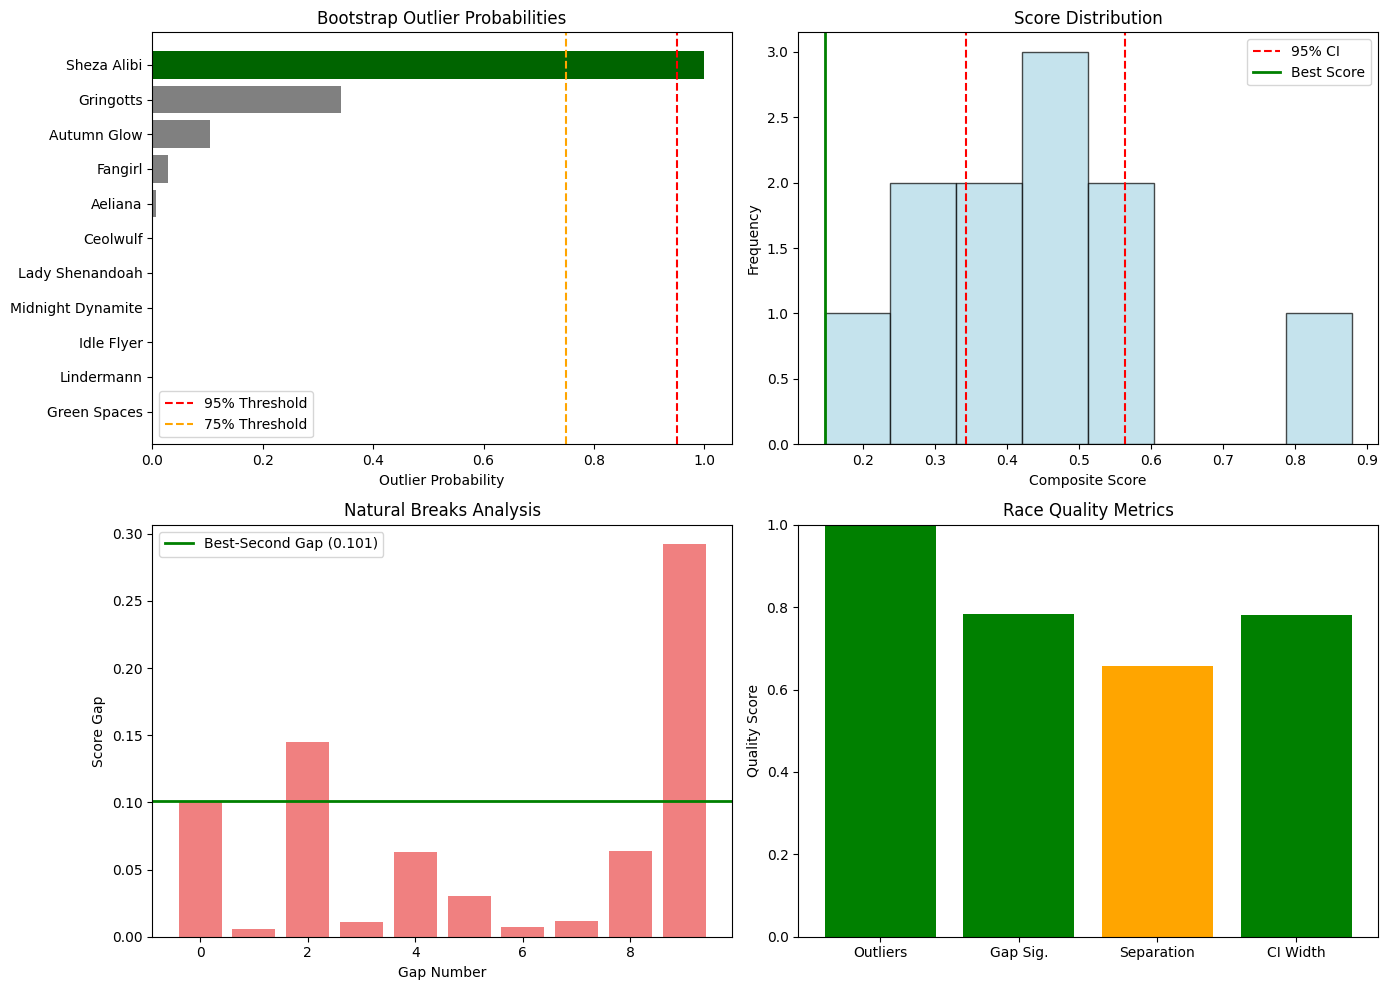


RACE ELIMINATION SUMMARY

Race Decision: SELECTIVE BET
Confidence: MODERATE

Key Findings:
- Top Outlier: Sheza Alibi (100.0% probability)
- Gap Significance: 78.4%
- Number of Clear Outliers (>95%): 1
- Number of Strong Contenders (>75%): 1

Recommendation:
- If "SELECTIVE BET" contains "BET": Focus on top 1 horses
- If "SELECTIVE BET" contains "SKIP": Look for better race



In [37]:
import pandas as pd
import numpy as np
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ============================
# YOUR COMPOSITE SCORES
# ============================

data = {
    "Tab": [14, 2, 8, 10, 9, 1, 12, 4, 11, 3, 7],
    "Horse": ["Sheza Alibi", "Gringotts", "Autumn Glow", "Fangirl", "Aeliana",
              "Ceolwulf", "Lady Shenandoah", "Midnight Dynamite", "Idle Flyer",
              "Lindermann", "Green Spaces"],
    "Composite_Score": [0.147, 0.248, 0.254, 0.399, 0.41, 0.473, 0.503, 0.51, 0.522, 0.586, 0.878]
}

df = pd.DataFrame(data)

# ============================
# BOOTSTRAP OUTLIER DETECTION
# ============================

def bootstrap_race_analysis(scores, n_bootstrap=10000, confidence_level=0.95):
    """
    Bootstrap-based outlier detection for a single race
    Returns confidence intervals and outlier probabilities
    """
    scores = np.array(scores)
    n_horses = len(scores)

    # Store bootstrap results
    bootstrap_means = []
    bootstrap_medians = []
    bootstrap_mins = []
    bootstrap_gaps = []  # Gap between best and second best

    # Bootstrap resampling
    for _ in range(n_bootstrap):
        # Resample with replacement
        sample = np.random.choice(scores, size=n_horses, replace=True)
        bootstrap_means.append(np.mean(sample))
        bootstrap_medians.append(np.median(sample))
        bootstrap_mins.append(np.min(sample))

        # Gap between best and second best
        sorted_sample = np.sort(sample)
        if len(sorted_sample) > 1:
            bootstrap_gaps.append(sorted_sample[1] - sorted_sample[0])

    # Calculate confidence intervals
    ci_low_mean = np.percentile(bootstrap_means, (1 - confidence_level) * 100 / 2)
    ci_high_mean = np.percentile(bootstrap_means, (1 + confidence_level) * 100 / 2)

    ci_low_median = np.percentile(bootstrap_medians, (1 - confidence_level) * 100 / 2)
    ci_high_median = np.percentile(bootstrap_medians, (1 + confidence_level) * 100 / 2)

    # Calculate outlier probability for each horse
    outlier_probs = []
    for score in scores:
        # Probability this score is an outlier (better than expected)
        prob = np.mean(bootstrap_mins >= score)  # How often is this score the minimum or better?
        outlier_probs.append(prob)

    # Calculate gap significance
    sorted_scores = np.sort(scores)
    best_score = sorted_scores[0]
    second_best = sorted_scores[1]
    actual_gap = second_best - best_score

    # Probability the observed gap is significant
    gap_prob = np.mean(bootstrap_gaps <= actual_gap)  # How often is the gap this large or larger?

    return {
        "mean_ci": (ci_low_mean, ci_high_mean),
        "median_ci": (ci_low_median, ci_high_median),
        "outlier_probs": np.array(outlier_probs), # Fix: Convert to numpy array for comparison
        "actual_gap": actual_gap,
        "gap_significance": gap_prob,
        "best_score": best_score,
        "second_best": second_best
    }

# Run bootstrap analysis
results = bootstrap_race_analysis(df["Composite_Score"].values)

# Add results to dataframe
df["Outlier_Prob"] = results["outlier_probs"]
df["Is_Outlier"] = df["Outlier_Prob"] > 0.95  # 95% confidence

# ============================
# RACE ELIMINATION CRITERIA
# ============================

def evaluate_race_quality(results, df):
    """
    Determine if a race is worth betting based on outlier analysis
    Returns decision and reasoning
    """
    reasons = []
    score = 0  # Higher score = better race to bet

    # Criterion 1: Clear outlier presence
    n_outliers = sum(results["outlier_probs"] > 0.95)
    if n_outliers >= 2:
        score += 3
        reasons.append(f"✅ {n_outliers} clear outliers identified")
    elif n_outliers == 1:
        score += 2
        reasons.append(f"⚠️ Only 1 clear outlier identified")
    else:
        score += 0
        reasons.append(f"❌ No clear outliers - competitive field")

    # Criterion 2: Gap significance
    gap_sig = results["gap_significance"]
    if gap_sig > 0.90:
        score += 3
        reasons.append(f"✅ Significant gap between best and rest ({gap_sig:.1%} confidence)")
    elif gap_sig > 0.75:
        score += 2
        reasons.append(f"⚠️ Moderate gap significance ({gap_sig:.1%} confidence)")
    else:
        score += 0
        reasons.append(f"❌ No significant gap - horses closely matched")

    # Criterion 3: Outlier probability separation
    probs = sorted(results["outlier_probs"], reverse=True)
    if len(probs) >= 2:
        separation = probs[0] - probs[1]
        if separation > 0.3:
            score += 3
            reasons.append(f"✅ Strong separation between top horses ({separation:.1%})")
        elif separation > 0.15:
            score += 2
            reasons.append(f"⚠️ Moderate separation ({separation:.1%})")
        else:
            score += 0
            reasons.append(f"❌ Weak separation - no clear hierarchy")

    # Criterion 4: Confidence interval tightness
    ci_width = results["mean_ci"][1] - results["mean_ci"][0]
    if ci_width < 0.1:
        score += 2
        reasons.append(f"✅ Tight confidence intervals (stable estimates)")
    elif ci_width < 0.2:
        score += 1
        reasons.append(f"⚠️ Moderate confidence intervals")
    else:
        score += 0
        reasons.append(f"❌ Wide confidence intervals (unstable estimates)")

    # Make decision
    if score >= 8:
        decision = "STRONG BET"
        confidence = "HIGH"
    elif score >= 6:
        decision = "SELECTIVE BET"
        confidence = "MODERATE"
    elif score >= 4:
        decision = "CAUTIOUS BET"
        confidence = "LOW"
    else:
        decision = "SKIP RACE"
        confidence = "VERY LOW"

    return decision, confidence, score, reasons

decision, confidence, score, reasons = evaluate_race_quality(results, df)

# ============================
# DISPLAY RESULTS
# ============================

print("=" * 80)
print("BOOTSTRAP RACE ELIMINATION SYSTEM")
print("=" * 80)

print("\nBootstrap Analysis Results:")
print(f"Mean Score 95% CI: [{results['mean_ci'][0]:.3f}, {results['mean_ci'][1]:.3f}]")
print(f"Median Score 95% CI: [{results['median_ci'][0]:.3f}, {results['median_ci'][1]:.3f}]")
print(f"Best Score: {results['best_score']:.3f}")
print(f"Second Best: {results['second_best']:.3f}")
print(f"Actual Gap: {results['actual_gap']:.3f}")
print(f"Gap Significance: {results['gap_significance']:.1%}")

print("\n\nOutlier Probabilities:")
df_sorted = df.sort_values("Outlier_Prob", ascending=False)
for _, row in df_sorted.iterrows():
    marker = "✅" if row["Outlier_Prob"] > 0.95 else "⚠️" if row["Outlier_Prob" ] > 0.75 else "  "
    print(f"   {marker} {row['Horse']:20s} - {row['Outlier_Prob']:.1%} outlier probability")

print("\n\n" + "=" * 80)
print("RACE EVALUATION")
print("=" * 80)

print(f"\nDecision: {decision}")
print(f"Confidence: {confidence}")
print(f"Score: {score}/11")

print("\nReasoning:")
for reason in reasons:
    print(f"   {reason}")

# ============================
# RAPID ELIMINATION CHECK
# ============================

print("\n\n" + "=" * 80)
print("RAPID ELIMINATION CHECK")
print("=" * 80)

# Quick checks to eliminate races
checks = {
    "Clear Top Horse": df["Outlier_Prob"].max() > 0.95,
    "Significant Gap": results["gap_significance"] > 0.75,
    "Top 3 Separation": len(df[df["Outlier_Prob"] > 0.75]) >= 3,
    "Not Too Competitive": df["Composite_Score"].std() > 0.15,
    "Not Too Spread": df["Composite_Score"].std() < 0.30
}

passed = sum(checks.values())
total = len(checks)

print(f"\nPassed {passed}/{total} quick checks:")

for check, passed_check in checks.items():
    if passed_check:
        print(f"   ✅ {check}")
    else:
        print(f"   ❌ {check}")

if passed >= 4:
    print("\n✅ RACE PASSES QUICK ELIMINATION - Proceed with detailed analysis")
elif passed >= 3:
    print("\n⚠️ RACE IS BORDERLINE - Proceed with caution")
else:
    print("\n❌ RACE FAILS QUICK ELIMINATION - Skip this race")

# ============================
# VISUALIZATION
# ============================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Outlier probabilities
colors = ['darkgreen' if p > 0.95 else 'green' if p > 0.75 else 'lightgreen' if p > 0.5 else 'gray'
          for p in df_sorted["Outlier_Prob"]]
axes[0, 0].barh(df_sorted["Horse"], df_sorted["Outlier_Prob"], color=colors)
axes[0, 0].axvline(x=0.95, color='red', linestyle='--', label='95% Threshold')
axes[0, 0].axvline(x=0.75, color='orange', linestyle='--', label='75% Threshold')
axes[0, 0].set_xlabel('Outlier Probability')
axes[0, 0].set_title('Bootstrap Outlier Probabilities')
axes[0, 0].invert_yaxis()
axes[0, 0].legend()

# Plot 2: Score distribution with confidence intervals
axes[0, 1].hist(df["Composite_Score"], bins=8, alpha=0.7, color='lightblue', edgecolor='black')
axes[0, 1].axvline(x=results['mean_ci'][0], color='red', linestyle='--', label='95% CI')
axes[0, 1].axvline(x=results['mean_ci'][1], color='red', linestyle='--')
axes[0, 1].axvline(x=results['best_score'], color='green', linewidth=2, label='Best Score')
axes[0, 1].set_xlabel('Composite Score')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Score Distribution')
axes[0, 1].legend()

# Plot 3: Gap analysis
sorted_scores = np.sort(df["Composite_Score"].values)
gaps = np.diff(sorted_scores)
axes[1, 0].bar(range(len(gaps)), gaps, color='lightcoral')
axes[1, 0].axhline(y=results['actual_gap'], color='green', linewidth=2,
                   label=f'Best-Second Gap ({results["actual_gap"]:.3f})')
axes[1, 0].set_xlabel('Gap Number')
axes[1, 0].set_ylabel('Score Gap')
axes[1, 0].set_title('Natural Breaks Analysis')
axes[1, 0].legend()

# Plot 4: Race quality score
quality_metrics = ['Outliers', 'Gap Sig.', 'Separation', 'CI Width']
quality_values = [
    sum(results["outlier_probs"] > 0.95),
    results["gap_significance"],
    sorted(results["outlier_probs"], reverse=True)[0] - sorted(results["outlier_probs"], reverse=True)[1],
    1 - (results["mean_ci"][1] - results["mean_ci"][0])
]
colors = ['green' if v > 0.7 else 'orange' if v > 0.4 else 'red' for v in quality_values]
axes[1, 1].bar(quality_metrics, quality_values, color=colors)
axes[1, 1].set_ylabel('Quality Score')
axes[1, 1].set_title('Race Quality Metrics')
axes[1, 1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# ============================
# SUMMARY
# ============================

print("\n" + "=" * 80)
print("RACE ELIMINATION SUMMARY")
print("=" * 80)

print(f"""
Race Decision: {decision}
Confidence: {confidence}

Key Findings:
- Top Outlier: {df_sorted.iloc[0]['Horse']} ({df_sorted.iloc[0]['Outlier_Prob']:.1%} probability)
- Gap Significance: {results['gap_significance']:.1%}
- Number of Clear Outliers (>95%): {sum(results['outlier_probs'] > 0.95)}
- Number of Strong Contenders (>75%): {sum(results['outlier_probs'] > 0.75)}

Recommendation:
- If \"{decision}\" contains \"BET\": Focus on top {sum(results['outlier_probs'] > 0.75)} horses
- If \"{decision}\" contains \"SKIP\": Look for better race
""")